# Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           mean_absolute_error, precision_recall_curve, roc_curve, auc)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os

C:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load SCADA Dataset

In [3]:
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

In [4]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

data['hour'] = data['timestamp'].dt.hour
data['month'] = data['timestamp'].dt.month

seasons_dict = {1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn', 12: 'Winter'}
data['seasons'] = data['month'].map(seasons_dict)

# EDA

## General Analysis

In [5]:
data.describe()

,plant_name,timestamp,wind_speed,turbulence_intensity,nacelle_direction,rotor_speed,generator_speed,blade_angle_1,blade_angle_2,blade_angle_3,...,bearing_temperature,hydraulic_pressure,gear_pressure,wind_direction,wind_speed_reference,airpressure,humidity,errorcode,hour,month
count,521729.000000,521729,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,...,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000
mean,114.803204,2021-07-12 04:43:15.370393600,0.623417,0.140167,198.947115,0.748144,0.726071,4.427931,4.415061,4.454174,...,41.072380,224.882010,2.209269,204.326081,0.677409,1011.706619,67.755695,0.124526,11.507520,6.552271
min,109.000000,2020-06-30 22:00:00,0.000007,0.000000,0.000000,0.000000,0.000350,-2.926377,-2.905175,-2.873115,...,20.000000,-6.000000,-4.000000,0.014008,0.017160,996.955994,3.287600,0.000000,0.000000,1.000000
25%,114.000000,2021-01-04 21:20:00,0.453608,0.085649,181.962392,0.580362,0.563297,-2.798157,-2.796227,-2.799953,...,38.000000,234.800598,2.000000,188.008390,0.508206,1009.190000,60.582901,0.000000,5.000000,4.000000
50%,115.000000,2021-07-12 00:00:00,0.623545,0.111587,198.893490,0.807482,0.783610,-2.665117,-2.703990,-2.600000,...,41.643372,235.068497,2.207413,204.335100,0.662334,1011.289980,70.998802,0.000000,12.000000,7.000000
75%,116.000000,2022-01-15 06:30:00,0.807051,0.149328,218.214512,0.991724,0.962340,3.853813,3.850743,3.854303,...,45.000000,235.628098,2.486693,223.014400,0.844128,1013.859990,81.070099,0.000000,18.000000,9.000000
max,120.000000,2022-08-01 00:00:00,1.895970,35.690361,359.994003,1.048668,1.017583,82.599998,82.599998,82.699997,...,54.000000,242.447800,3.612000,359.960999,1.639800,1028.000000,97.353897,1.000000,23.000000,12.000000
std,3.547718,NaN,0.245780,0.307267,49.610009,0.269967,0.261822,18.863197,18.848045,18.883474,...,5.057857,47.410284,0.512313,50.725445,0.244888,3.874168,18.387538,0.330181,6.948847,3.393526


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521729 entries, 0 to 521728
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   plant_name             521729 non-null  int64         
 1   timestamp              521729 non-null  datetime64[ns]
 2   wind_speed             521729 non-null  float64       
 3   turbulence_intensity   521729 non-null  float64       
 4   nacelle_direction      521729 non-null  float64       
 5   rotor_speed            521729 non-null  float64       
 6   generator_speed        521729 non-null  float64       
 7   blade_angle_1          521729 non-null  float64       
 8   blade_angle_2          521729 non-null  float64       
 9   blade_angle_3          521729 non-null  float64       
 10  power                  521729 non-null  float64       
 11  cosphi                 521729 non-null  float64       
 12  temp_environment       521729 non-null  floa

In [7]:
# ===== 1. Create unified figures directory =====
figures_dir = 'figures'
os.makedirs(figures_dir, exist_ok=True)

# ===== 2. Set consistent white background style =====
plt.style.use('default')  # Reset to default style first
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'grid.color': '#dddddd',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})
sns.set_style("white")  # Set seaborn style

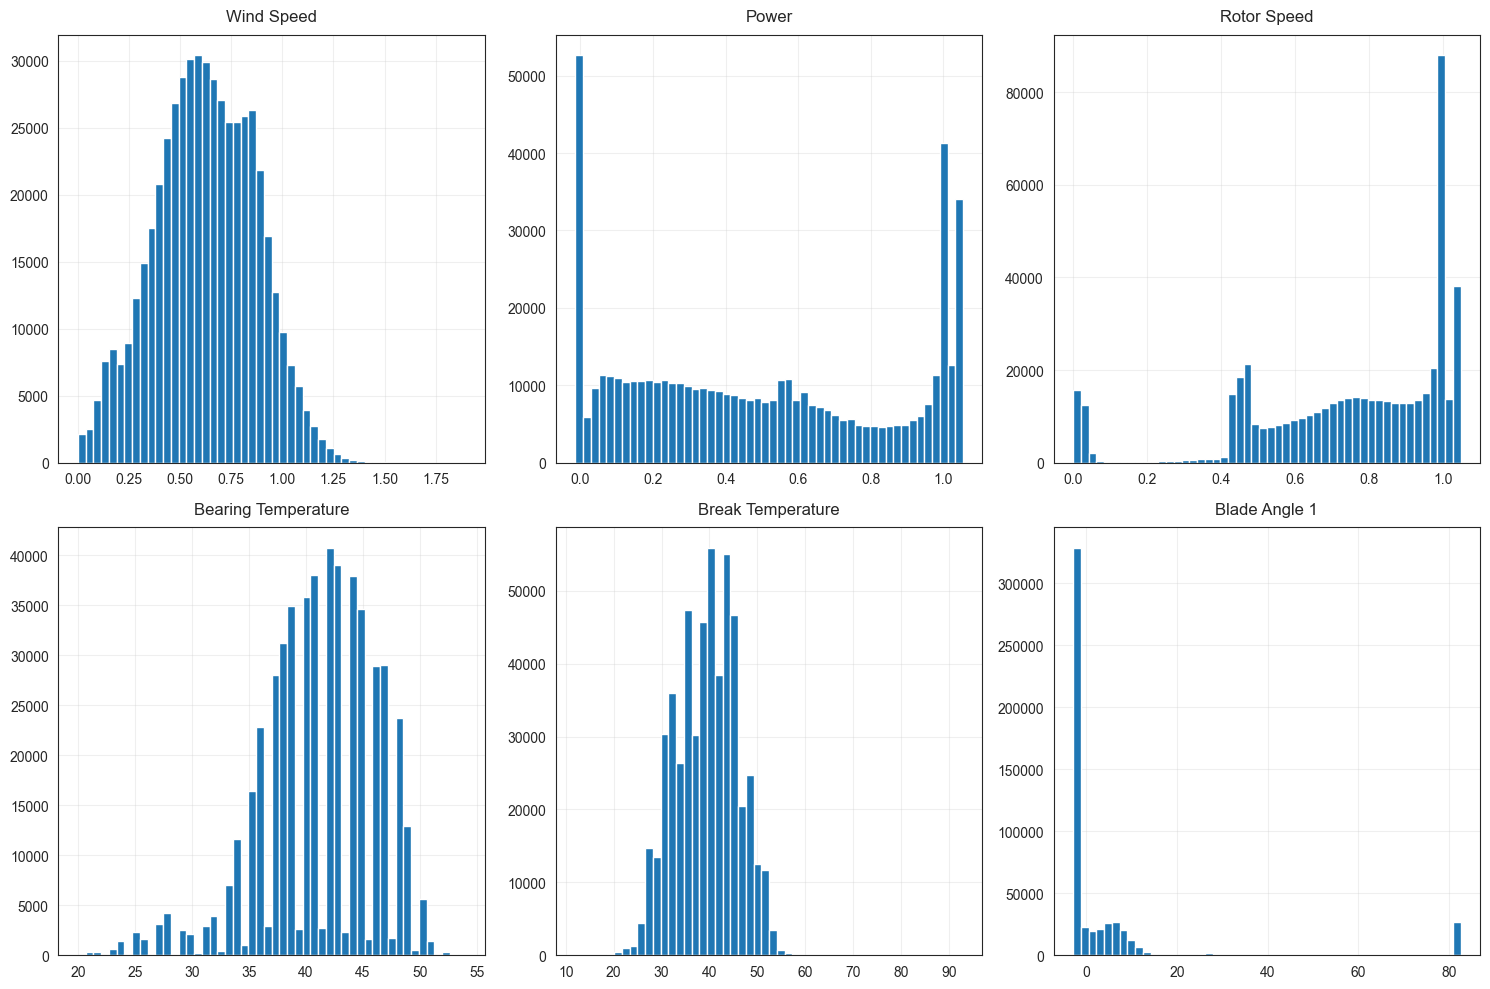

In [8]:
# ===== 3. Histograms (6 features) =====
features = ['wind_speed', 'power', 'rotor_speed', 'bearing_temperature', 'break_temperature', 'blade_angle_1']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, feature in zip(axes.flatten(), features):
    data[feature].hist(bins=50, ax=ax, color='#1f77b4')
    ax.set_title(feature.replace("_", " ").title(), pad=10)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feature_histograms.png'), dpi=300, bbox_inches='tight')
plt.show()

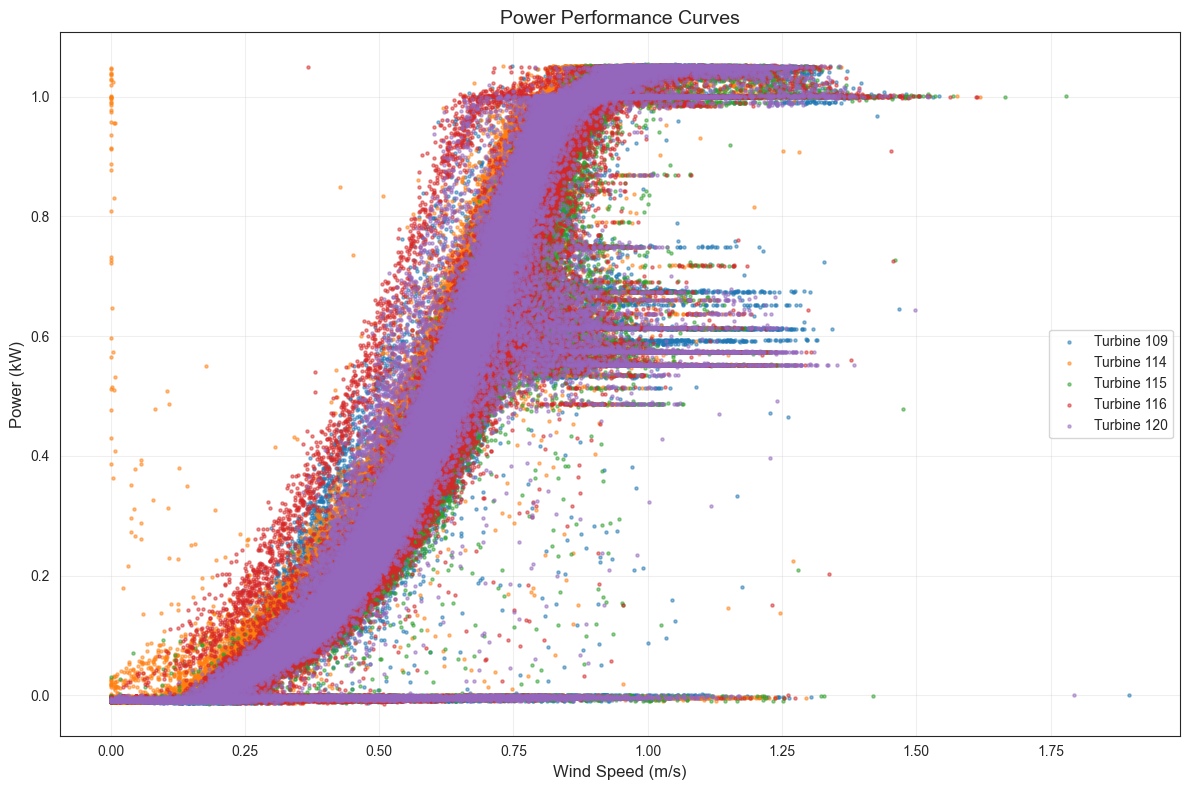

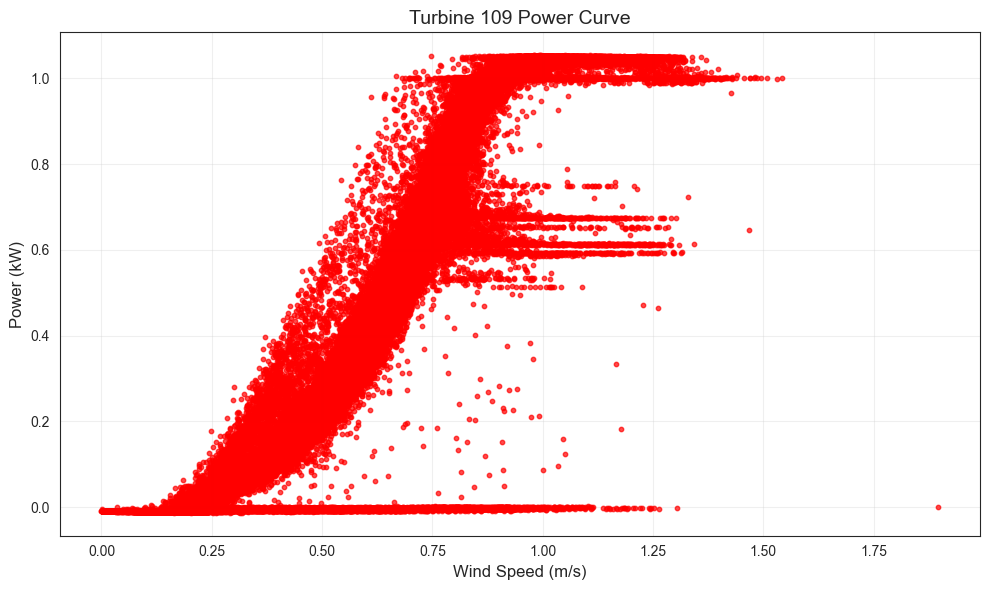

In [9]:
# ===== 4. Power Curves (All Turbines + Turbine 109) =====
# All turbines
plt.figure(figsize=(12, 8))
for turbine in data['plant_name'].unique():
    turbine_data = data[data['plant_name'] == turbine]
    plt.scatter(turbine_data['wind_speed'], turbine_data['power'],
               alpha=0.5, s=5, label=f'Turbine {turbine}')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('Power Performance Curves', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'all_turbines_power_curves.png'), dpi=300)
plt.show()

# Turbine 109
turbine_109 = data[data['plant_name'] == 109]
plt.figure(figsize=(10, 6))
plt.scatter(turbine_109['wind_speed'], turbine_109['power'],
           alpha=0.7, s=10, color='red')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('Turbine 109 Power Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'turbine109_power_curve.png'), dpi=300)
plt.show()


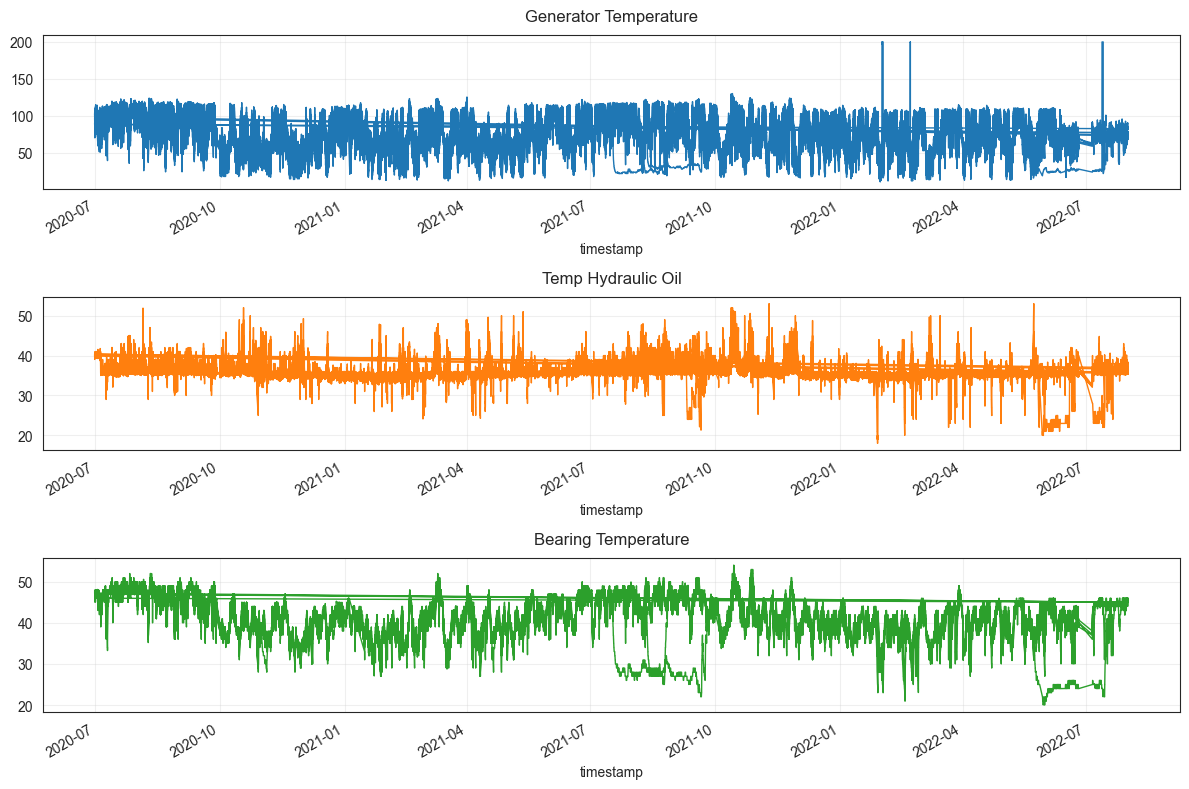

In [10]:
# ===== 5. Temperature Time Series =====
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for ax, col, temp_col in zip(axes, colors, ['generator_temperature', 'temp_hydraulic_oil', 'bearing_temperature']):
    data.set_index('timestamp')[temp_col].plot(ax=ax, color=col, linewidth=1)
    ax.set_title(temp_col.replace("_", " ").title(), pad=10)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'temperature_timeseries.png'), dpi=300)
plt.show()

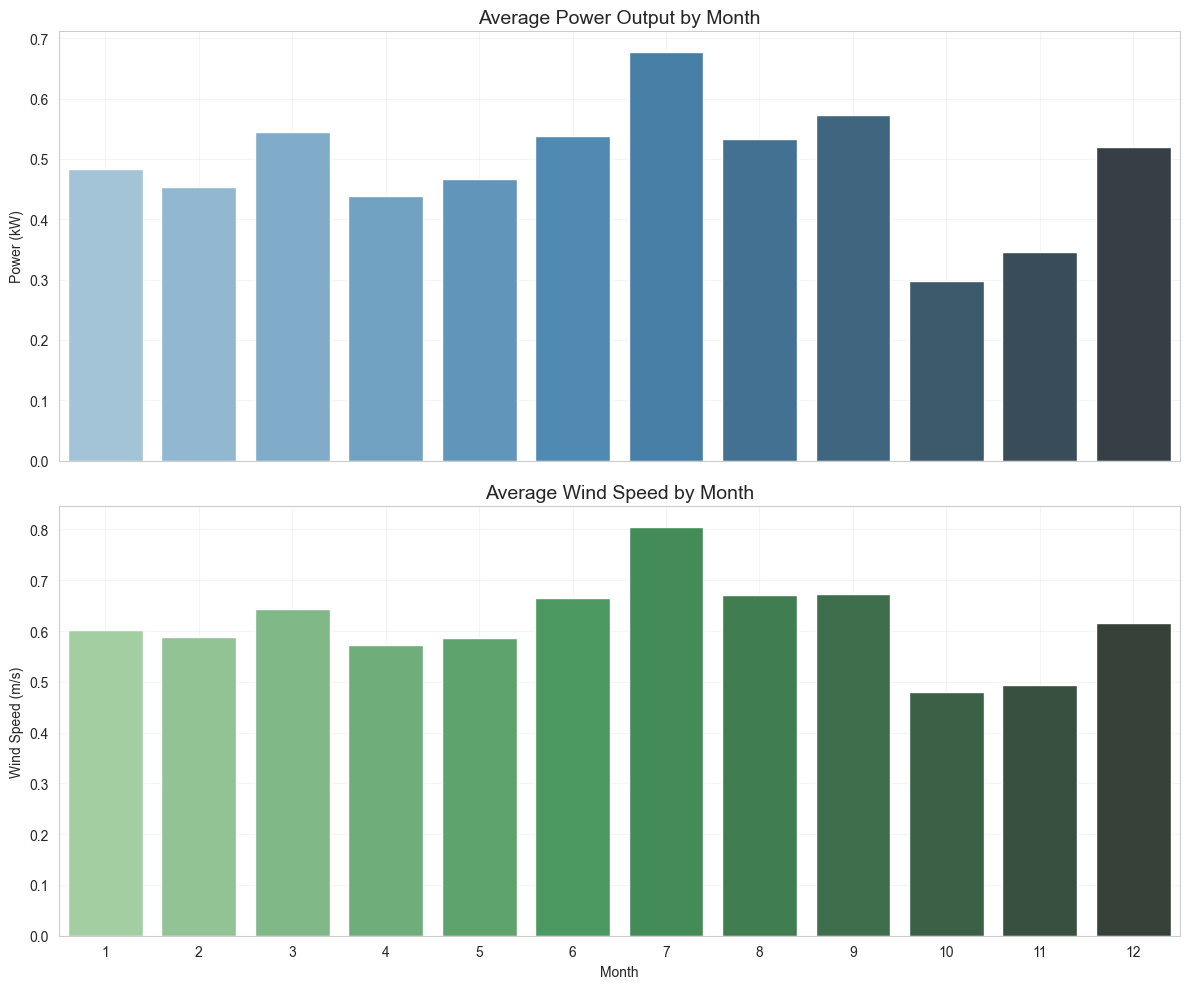

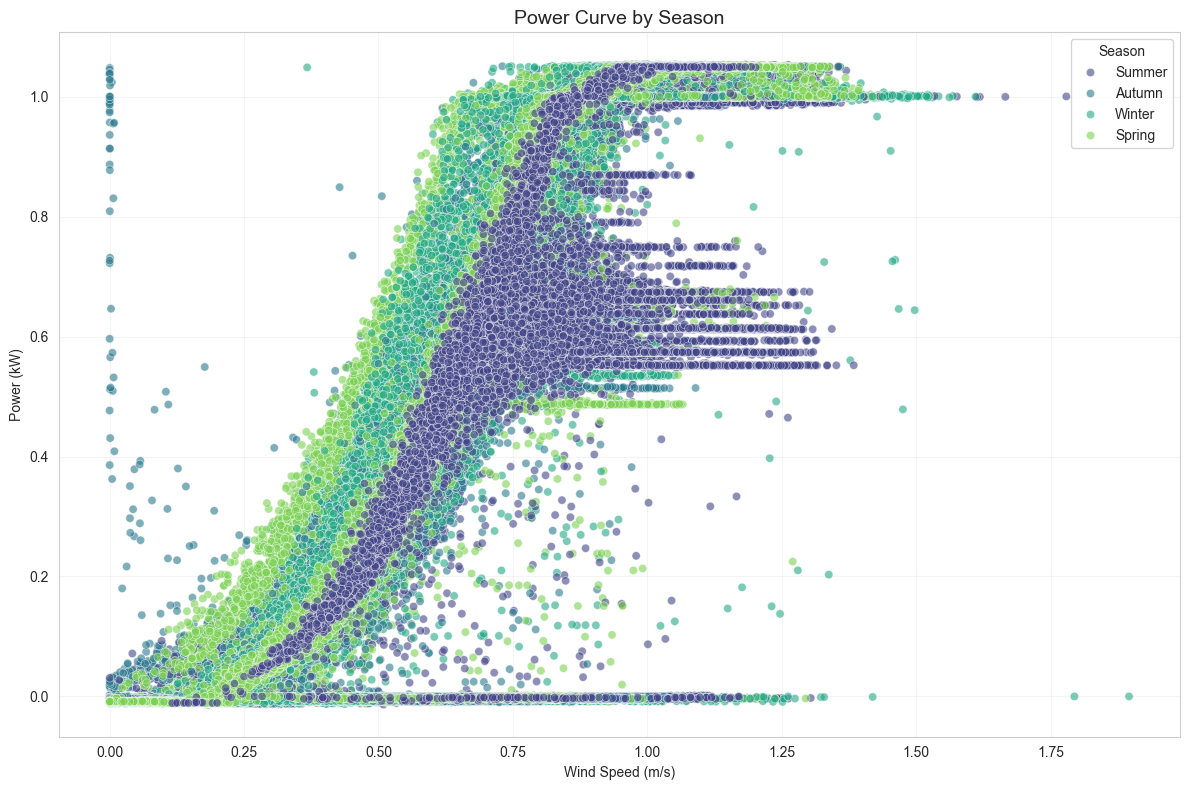

Monthly and seasonal plots saved to 'figures' directory


In [11]:
# Create figures directory if needed
os.makedirs('figures', exist_ok=True)

# Set style
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'grid.color': '#dddddd'
})

# ===== 1. Monthly Average Power and Wind Speed =====
monthly_avg = data.groupby('month').agg({
    'power': 'mean',
    'wind_speed': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Power plot
sns.barplot(data=monthly_avg, x='month', y='power',
           palette='Blues_d', ax=ax1)
ax1.set_title('Average Power Output by Month', fontsize=14)
ax1.set_ylabel('Power (kW)')
ax1.grid(True, alpha=0.3)

# Wind speed plot
sns.barplot(data=monthly_avg, x='month', y='wind_speed',
           palette='Greens_d', ax=ax2)
ax2.set_title('Average Wind Speed by Month', fontsize=14)
ax2.set_ylabel('Wind Speed (m/s)')
ax2.set_xlabel('Month')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/monthlypower.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== 2. Seasonal Scatter Plot =====
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='wind_speed', y='power',
               hue='seasons', palette='viridis', alpha=0.6)
plt.title('Power Curve by Season', fontsize=14)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.grid(True, alpha=0.3)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('figures/seasonalpower.png', dpi=300, bbox_inches='tight')
plt.show()

print("Monthly and seasonal plots saved to 'figures' directory")

# Feature Engineering

In [12]:
data.isna().sum()

plant_name               0
timestamp                0
wind_speed               0
turbulence_intensity     0
nacelle_direction        0
rotor_speed              0
generator_speed          0
blade_angle_1            0
blade_angle_2            0
blade_angle_3            0
power                    0
cosphi                   0
temp_environment         0
generator_temperature    0
break_temperature        0
temp_hydraulic_oil       0
bearing_temperature      0
hydraulic_pressure       0
gear_pressure            0
wind_direction           0
wind_speed_reference     0
airpressure              0
humidity                 0
errorcode                0
hour                     0
month                    0
seasons                  0
dtype: int64

In [13]:
print("Fault class distribution:\n", data["errorcode"].value_counts())  # Assuming 'errorcode' is the target

Fault class distribution:
 errorcode
0    456760
1     64969
Name: count, dtype: int64
